- yfinance 설치

In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 46.9 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15703 sha256=e3f2cb21e07719053d28de81b8517c8fbc3ba69e05896a05dc1cb0501be78da0
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cf

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


- 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import yfinance as yf

- 애플의 1년치 데이터 다운로드 후 일부데이터 출력, 데이터 크기 출력
- 야후파이낸스에서 지정한 티커(종목코드) 기준
- 애플의 티커는 AAPL

In [3]:
# 애플(AAPL)의 1년치 데이터 다운로드
# (삼성전자를 보고 싶다면 '005930.KS'를 넣으면 됩니다)
df = yf.download('AAPL', period='1y') 
df
# 데이터가 잘 왔는지 확인 (날짜, 종가, 고가, 저가, 시가, 거래량 등이 보입니다)


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-03-04,234.906174,239.028223,233.661598,236.678463,53798100
2025-03-05,234.716995,235.523478,228.235236,234.398377,47227600
2025-03-06,234.308792,236.827812,232.148211,233.422655,45170400
2025-03-07,238.032562,240.322569,233.741253,234.089740,46273600
2025-03-10,226.492844,235.135185,223.246996,234.517865,72071200
...,...,...,...,...,...
2026-02-25,274.230011,274.940002,271.049988,271.779999,33714300
2026-02-26,272.950012,276.109985,270.799988,274.950012,32345100


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-03-04 to 2026-03-03
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   251 non-null    float64
 1   (High, AAPL)    251 non-null    float64
 2   (Low, AAPL)     251 non-null    float64
 3   (Open, AAPL)    251 non-null    float64
 4   (Volume, AAPL)  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [14]:
# 거래량이 가장 많았던 날 찾기
max_volume_day = df[df['Volume', 'AAPL'] == df['Volume', 'AAPL'].max()]
max_volume_day

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-04-09,197.987106,199.739463,171.144091,171.203828,184395900


In [15]:
# 가격과 거래량의 상관관계 확인 (보통 0.5 이상이면 관계가 깊다고 봅니다)
correlation = df['Close', 'AAPL'].corr(df['Volume', 'AAPL'])
correlation

np.float64(-0.2852138257846792)

- 컬럼명과 인덱스 출력

In [57]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA60', 'Upper',
       'Lower', 'RSI'],
      dtype='object', name='Price')

In [58]:
df.index

DatetimeIndex(['2025-03-04', '2025-03-05', '2025-03-06', '2025-03-07',
               '2025-03-10', '2025-03-11', '2025-03-12', '2025-03-13',
               '2025-03-14', '2025-03-17',
               ...
               '2026-02-18', '2026-02-19', '2026-02-20', '2026-02-23',
               '2026-02-24', '2026-02-25', '2026-02-26', '2026-02-27',
               '2026-03-02', '2026-03-03'],
              dtype='datetime64[ns]', name='Date', length=251, freq=None)

- 결측치 확인
- 결측치 채우기( 앞의 데이터로 채우기 : ffill , 뒤의 데이터로 채우기 : bfill )

In [2]:
# 빈칸(결측치)이 있는지 확인
df.isnull().sum()

# 만약 빈칸이 있다면, 바로 전날의 가격으로 채워넣기 (ffill: forward fill)
df = df.ffill()

# 데이터 정보 최종 확인 (날짜 타입, 숫자 타입 등이 맞는지 점검)
df.info()

- 종가를 기준으로 이동평균 계산
- 이동평균은 판다스의 rolling(개수).mean() 함수 사용

In [19]:
# 종가(Close)를 기준으로 이동평균 계산

# 20일 이동평균선 (창문을 20개씩 옆으로 밀며 평균 구하기)
df['MA20'] = df['Close'].rolling(window=20).mean()

# 60일 이동평균선
df['MA60'] = df['Close'].rolling(window=60).mean()

# 계산된 결과 확인 (앞부분 20일은 데이터가 부족해 NaN으로 나옵니다)
df.head(30)

Price,Close,High,Low,Open,Volume,MA20,MA60
Date,,,,,,,
2025-03-04,234.906174,239.028223,233.661598,236.678463,53798100,NaN,NaN
2025-03-05,234.716995,235.523478,228.235236,234.398377,47227600,NaN,NaN
2025-03-06,234.308792,236.827812,232.148211,233.422655,45170400,NaN,NaN
2025-03-07,238.032562,240.322569,233.741253,234.089740,46273600,NaN,NaN
2025-03-10,226.492844,235.135185,223.246996,234.517865,72071200,NaN,NaN
2025-03-11,219.881653,224.859955,216.506364,222.838766,76137400,NaN,NaN
2025-03-12,216.038406,220.787711,213.977397,219.184697,62547500,NaN,NaN
2025-03-13,208.770081,215.899013,207.515554,215.012876,61368300,NaN,NaN
2025-03-14,212.563553,213.021548,208.670517,210.333268,60107600,NaN,NaN


- 시각화
- 실제 주가와 20일 이동평균선, 60일 이동평균선 출력
- 범례와 격자 출력

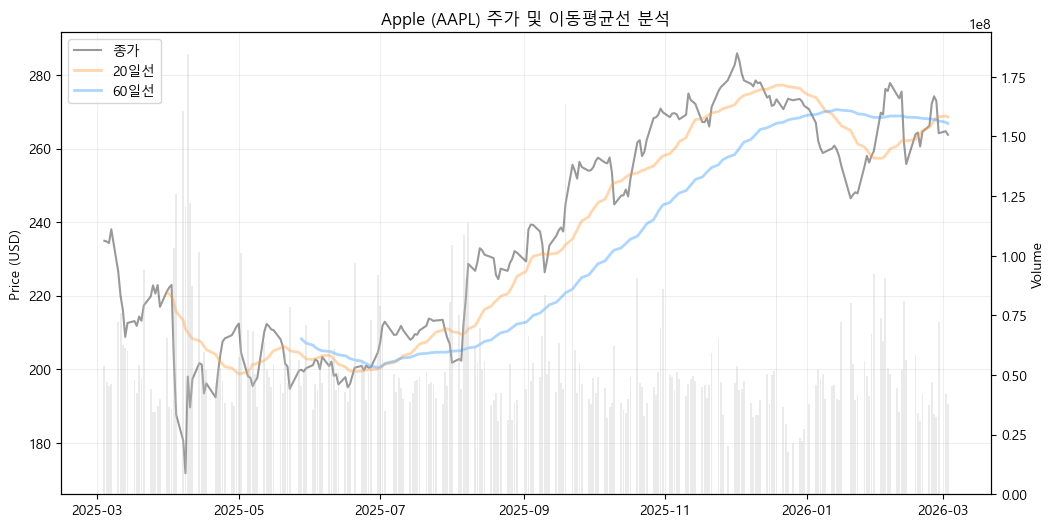

In [49]:
# 그래프 크기 키우기
fig, ax1 = plt.subplots(figsize=(12, 6))
# 1. 실제 주가 (얇은 선)
ax1.plot(df.index, df['Close'], color='black', label='종가', alpha=0.4)
# 2. 20일 이동평균선 (주황색, 단기 추세)
ax1.plot(df.index, df['MA20'], color='#ff9933', label='20일선', linewidth=2, alpha=0.4)
# 3. 60일 이동평균선 (파란색, 중기 추세)
ax1.plot(df.index, df['MA60'], color='#3399ff', label='60일선', linewidth=2, alpha=0.4)

ax1.set_ylabel('Price (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.2)

# 거래량 (흐리게 배경처럼)
ax2 = ax1.twinx()
ax2.bar(df.index, df['Volume'], color='silver', alpha=0.3)
ax2.set_ylabel('Volume')

plt.title('Apple (AAPL) 주가 및 이동평균선 분석')
plt.show()

In [50]:
import yfinance as yf

aapl = yf.Ticker("AAPL")

# 1. 기업 개요 요약 보기 (시가총액, PER 등)
print(aapl.info['marketCap'])
print(aapl.info['forwardPE'])

# 2. 최근 배당 내역 확인
print(aapl.dividends.tail())

# 3. 올해 매출액 확인 (재무제표)
print(aapl.income_stmt)

3876577869824
28.31707
Date
2025-02-10 00:00:00-05:00    0.25
2025-05-12 00:00:00-04:00    0.26
2025-08-11 00:00:00-04:00    0.26
2025-11-10 00:00:00-05:00    0.26
2026-02-09 00:00:00-05:00    0.26
Name: Dividends, dtype: float64
                                                      2025-09-30  \
Tax Effect Of Unusual Items                         0.000000e+00   
Tax Rate For Calcs                                  1.560000e-01   
Normalized EBITDA                                   1.447480e+11   
Net Income From Continuing Operation Net Minori...  1.120100e+11   
Reconciled Depreciation                             1.169800e+10   
Reconciled Cost Of Revenue                          2.209600e+11   
EBITDA                                              1.447480e+11   
EBIT                                                1.330500e+11   
Net Interest Income                                          NaN   
Interest Expense                                             NaN   
Interest Income       

In [54]:
import yfinance as yf
import pandas as pd

# 데이터 받기
df = yf.download('AAPL', period='1y')

# 기존 이동평균선
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()

# 1. 이중 컬럼 구조를 단일 컬럼으로 변경 (중요!)
df.columns = df.columns.get_level_values(0)

# 2. 이제 계산이 에러 없이 돌아갑니다.
std = df['Close'].rolling(window=20).std()
df['Upper'] = df['MA20'] + (std * 2)
df['Lower'] = df['MA20'] - (std * 2)

# 3. RSI 계산 부분도 그대로 진행
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -1 * delta.clip(upper=0)
ema_up = up.ewm(com=13, adjust=False).mean()
ema_down = down.ewm(com=13, adjust=False).mean()
rs = ema_up / ema_down
df['RSI'] = 100 - (100 / (1 + rs))

print("계산 완료!")

[*********************100%***********************]  1 of 1 completed

계산 완료!


In [56]:
df

Price,Close,High,Low,Open,Volume,MA20,MA60,Upper,Lower,RSI
Date,,,,,,,,,,
2025-03-04,234.906174,239.028223,233.661598,236.678463,53798100,NaN,NaN,NaN,NaN,NaN
2025-03-05,234.717010,235.523493,228.235251,234.398392,47227600,NaN,NaN,NaN,NaN,0.000000
2025-03-06,234.308792,236.827812,232.148211,233.422655,45170400,NaN,NaN,NaN,NaN,0.000000
2025-03-07,238.032562,240.322569,233.741253,234.089740,46273600,NaN,NaN,NaN,NaN,58.308724
2025-03-10,226.492844,235.135185,223.246996,234.517865,72071200,NaN,NaN,NaN,NaN,19.792875
...,...,...,...,...,...,...,...,...,...,...
2026-02-25,274.230011,274.940002,271.049988,271.779999,33714300,267.472775,267.929976,282.091499,252.854051,58.741212
2026-02-26,272.950012,276.109985,270.799988,274.950012,32345100,268.310262,267.835988,282.105853,254.514670,57.168436
2026-02-27,264.179993,272.809998,262.890015,272.809998,72366500,268.617334,267.525065,281.705514,255.529154,47.737419


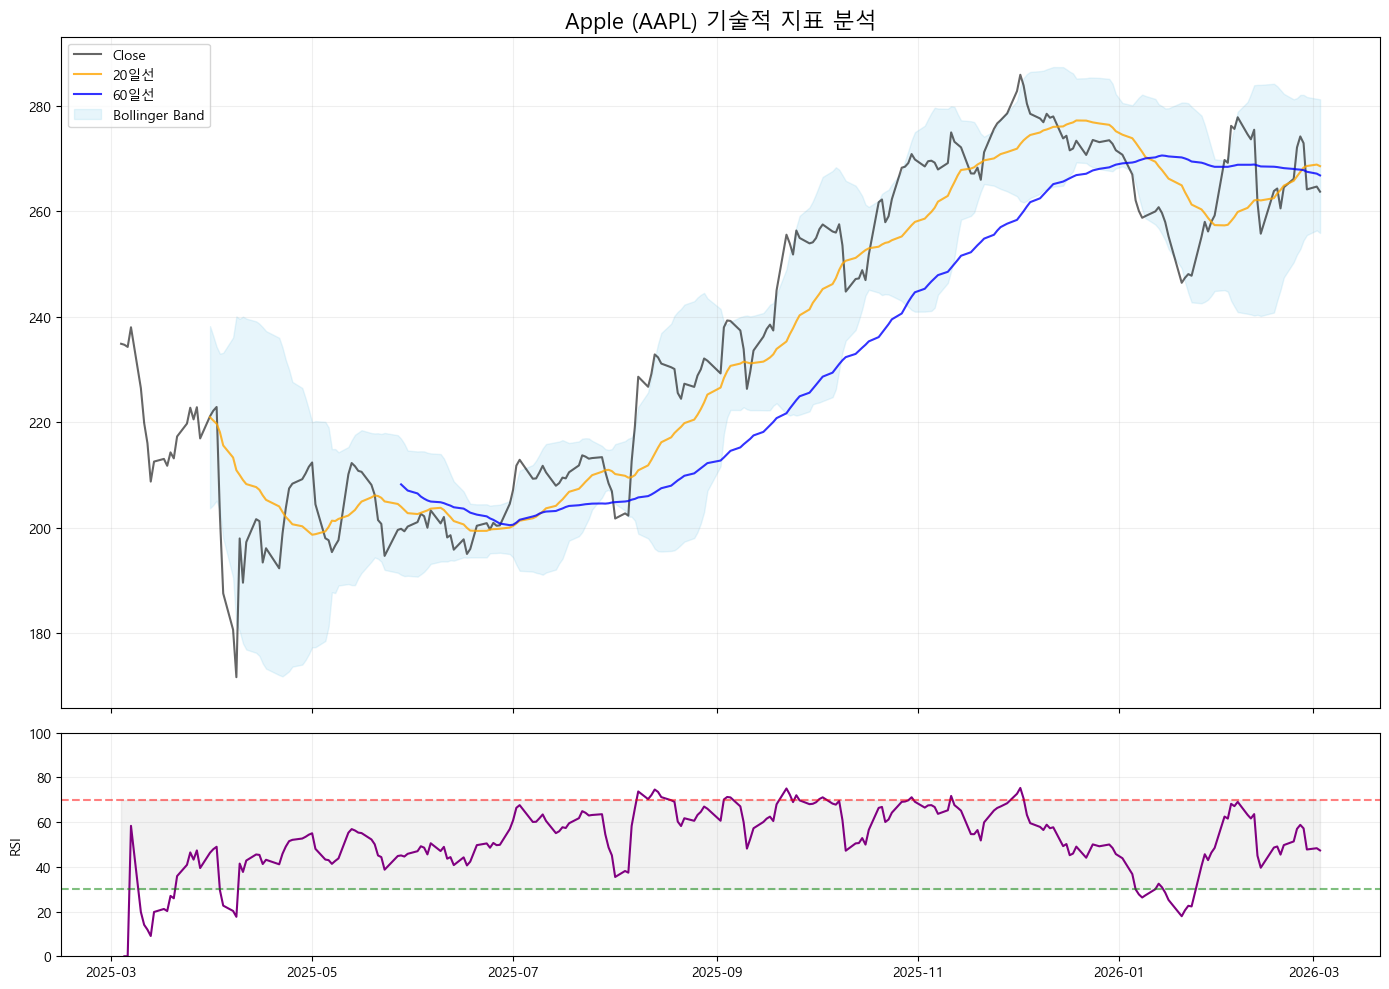

In [55]:
import matplotlib.pyplot as plt

# 폰트 설정 (에러 없는 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 두 개의 차트 생성 (비율 3:1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# --- 상단 차트: 주가 + 이동평균선 + 볼린저 밴드 ---
ax1.plot(df.index, df['Close'], color='black', label='Close', alpha=0.6)
ax1.plot(df.index, df['MA20'], color='orange', label='20일선', alpha=0.8)
ax1.plot(df.index, df['MA60'], color='blue', label='60일선', alpha=0.8)

# 볼린저 밴드 영역 채우기 (눈 편한 연한 하늘색)
ax1.fill_between(df.index, df['Lower'], df['Upper'], color='skyblue', alpha=0.2, label='Bollinger Band')
ax1.set_title('Apple (AAPL) 기술적 지표 분석', fontsize=16)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.2)

# --- 하단 차트: RSI (과열/침체 지표) ---
ax2.plot(df.index, df['RSI'], color='purple', label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5) # 과열 기준선
ax2.axhline(30, color='green', linestyle='--', alpha=0.5) # 침체 기준선
ax2.fill_between(df.index, 30, 70, color='gray', alpha=0.1) # 정상 범위 음영
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# yfinance는 단순히 일일 주가뿐만 아니라 기업의 재무제표, 배당 내역, 분석가 전망 등 엄청나게 방대한 데이터를 제공합니다. 
# 주식 시장의 "종합 선물 세트"라고 보셔도 돼요.

# 주요 정보들을 카테고리별로 정리해 드릴게요. (코드 예시는 애플 aapl 기준입니다.)

# 1. 기본 주가 및 거래 정보 (OHLCV)
# 질문하신 시가, 고가, 저가, 종가, 거래량 외에도 **수정 종가(Adj Close)**가 중요합니다.

# 수정 종가: 배당이나 주식 분할 같은 이벤트가 반영된 진짜 가격입니다. (백테스팅할 때 필수!)

# 2. 기업의 기초 체력 (재무제표)
# 기업이 돈을 얼마나 잘 버는지 바로 확인할 수 있습니다.

# aapl.income_stmt: 손익계산서 (매출, 영업이익, 순이익 등)

# aapl.balance_sheet: 대차대조표 (자산, 부채, 자본)

# aapl.cashflow: 현금흐름표 (영업활동 현금흐름 등)

# 3. 투자자에게 중요한 정보 (배당 및 주식분할)
# 주주라면 꼭 챙겨야 할 데이터죠.

# aapl.dividends: 배당금 지급 내역 (날짜별 금액)

# aapl.splits: 주식 분할 내역 (예: 1:4 분할 등)

# aapl.actions: 배당과 분할 정보를 한꺼번에 보여줍니다.

# 4. 전문가들의 의견 (분석가 리포트)
# 월가 전문가들이 이 주식을 어떻게 보는지 알 수 있습니다.

# aapl.recommendations: 매수/매도 의견 (Buy, Hold, Sell 등)

# aapl.calendar: 다음 실적 발표일이 언제인지 알려줍니다.

# 5. 실시간 정보 및 상세 프로필
# aapl.info: 기업의 시가총액, PER, PBR, 직원 수, 기업 개요 등 수백 가지 세부 항목을 딕셔너리 형태로 반환합니다.

# aapl.major_holders: 주요 주주(기관, 내부자) 비중을 보여줍니다.